
# 08 Capstone: A Working Land Parcel Verification Engine

Every notebook before this one taught one library in isolation. This one puts them together into a
single, working `LandVerificationEngine` class a **miniature but functionally real version of the
geospatial module** described in the land banking platform's system architecture (the "Geospatial"
module in the Python microservice, sitting alongside Computer Vision and Risk Models).

This is deliberately structured the way the real product's code would be structured, not as one long
script by the end, you'll see exactly how this maps onto real files in the actual codebase.

## What this engine does

Given a new parcel submission (a shape, an address, a price), it will:

1. **Check for duplicate-sale conflicts** against existing parcels (notebooks 01, 05)
2. **Compute the parcel's real area** in hectares, correctly projected (notebook 03)
3. **Geocode the submitted address** if coordinates weren't provided directly (notebook 04)
4. **Score proximity to key infrastructure** (notebook 01's buffer operations + notebook 03's real
   distances)
5. **Flag whether the parcel sits in a high-value spatial cluster**, using the existing portfolio's
   price pattern (notebook 06)
6. **Generate a structured due diligence summary** the exact shape of data an LLM (per the product's
   build matrix) would turn into a readable report for a buyer or investor

## Step 1: the existing parcel inventory

Simulating what would really be loaded from PostGIS (notebook 07) in production.


Loaded 150 existing parcels into the inventory.


<Axes: >

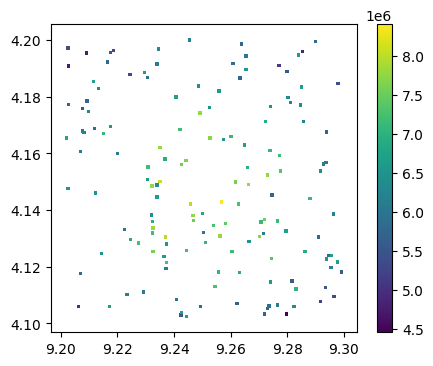

In [2]:

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import box, Point, LineString
from libpysal.weights import KNN
from esda.moran import Moran_Local

np.random.seed(11)
n = 150
town_center = (9.25, 4.15)
xs = np.random.uniform(9.20, 9.30, n)
ys = np.random.uniform(4.10, 4.20, n)
dist_from_center = np.sqrt((xs - town_center[0])**2 + (ys - town_center[1])**2)
price = np.clip(8_000_000 - dist_from_center * 40_000_000 + np.random.normal(0, 500_000, n), 500_000, None)

existing_parcels = gpd.GeoDataFrame({
    "parcel_id": [f"PARC-{i:04d}" for i in range(n)],
    "owner_name": np.random.choice(["Ekotto Land Holdings", "Mballa Family Trust", "Nkemayang Estates"], n),
    "price_xaf": price,
    "geometry": [box(x, y, x + 0.0012, y + 0.0012) for x, y in zip(xs, ys)],
}, crs="EPSG:4326")

print(f"Loaded {len(existing_parcels)} existing parcels into the inventory.")
existing_parcels.plot(column="price_xaf", cmap="viridis", legend=True, figsize=(5, 4))



## Step 2: key infrastructure reference data

A small dataset of things that affect land value a main road and a planned market the kind of data
that would come from the infrastructure-impact forecasting feature in a real system.


In [3]:

infrastructure = gpd.GeoDataFrame({
    "name": ["Main ring road", "Planned central market"],
    "type": ["road", "market"],
    "geometry": [
        LineString([(9.20, 4.145), (9.30, 4.155)]),
        Point(9.26, 4.16),
    ],
}, crs="EPSG:4326")

infrastructure


,name,type,geometry
0,Main ring road,road,"LINESTRING (9.2 4.145, 9.3 4.155)"
1,Planned central market,market,POINT (9.26 4.16)



## Step 3: build the engine

This is written as a class the same shape a real `geospatial_engine.py` service file would take. Read
through each method's docstring; each one is a direct callback to one of the earlier notebooks.


In [4]:

PROJECTED_CRS = "EPSG:32632"  # UTM Zone 32N correct for the Douala/Buea area, see notebook 03

class LandVerificationEngine:
    def __init__(self, existing_parcels: gpd.GeoDataFrame, infrastructure: gpd.GeoDataFrame):
        self.parcels = existing_parcels
        self.infrastructure = infrastructure
        self._weights = None  # built lazily, see cluster_score()

    def check_duplicate_sale(self, new_geom):
        """Notebook 05 pattern: use the spatial index, not a brute-force loop."""
        candidate_positions = self.parcels.sindex.query(new_geom, predicate="intersects")
        return self.parcels.iloc[candidate_positions]

    def real_area_hectares(self, geom):
        """Notebook 03 pattern: never trust .area on raw lat/lon geometry."""
        gs = gpd.GeoSeries([geom], crs="EPSG:4326").to_crs(PROJECTED_CRS)
        return gs.iloc[0].area / 10_000

    def infrastructure_proximity(self, geom, buffer_meters=500):
        """Notebook 01 + 03 pattern: project first, then buffer in real meters."""
        geom_projected = gpd.GeoSeries([geom], crs="EPSG:4326").to_crs(PROJECTED_CRS).iloc[0]
        infra_projected = self.infrastructure.to_crs(PROJECTED_CRS)

        results = []
        for _, row in infra_projected.iterrows():
            distance = geom_projected.distance(row["geometry"])
            results.append({
                "infrastructure": row["name"],
                "type": row["type"],
                "distance_meters": round(distance, 1),
                "within_buffer": distance <= buffer_meters,
            })
        return results

    def _ensure_weights(self):
        if self._weights is None:
            coords = np.array(list(zip(self.parcels.geometry.centroid.x, self.parcels.geometry.centroid.y)))
            self._weights = KNN.from_array(coords, k=5)
            self._weights.transform = "r"
        return self._weights

    def cluster_context(self, new_geom, new_price_estimate):
        """Notebook 06 pattern: is this new parcel's estimated price consistent with a
        high-value cluster nearby, based on the existing portfolio's spatial pattern?"""
        w = self._ensure_weights()
        temp_prices = np.append(self.parcels["price_xaf"].values, new_price_estimate)
        temp_coords = np.vstack([
            np.array(list(zip(self.parcels.geometry.centroid.x, self.parcels.geometry.centroid.y))),
            [[new_geom.centroid.x, new_geom.centroid.y]],
        ])
        temp_w = KNN.from_array(temp_coords, k=5)
        temp_w.transform = "r"
        lisa = Moran_Local(temp_prices, temp_w)

        quadrant_labels = {1: "High-High (hot spot)", 2: "Low-High (opportunity)",
                            3: "Low-Low (cold spot)", 4: "High-Low (outlier)"}
        new_parcel_result = lisa.q[-1]
        significant = lisa.p_sim[-1] < 0.05
        return {
            "cluster_type": quadrant_labels[new_parcel_result],
            "statistically_significant": bool(significant),
        }

    def generate_due_diligence_report(self, new_geom, submitted_price, owner_claim):
        """
        Combines every check above into one structured record deliberately shaped as
        clean structured data, ready to be handed to an LLM for the actual due-diligence
        report generation feature (per the product's build matrix: LLM summarizes verified
        data, it never invents any of it).
        """
        conflicts = self.check_duplicate_sale(new_geom)
        area_ha = self.real_area_hectares(new_geom)
        proximity = self.infrastructure_proximity(new_geom)
        cluster = self.cluster_context(new_geom, submitted_price)

        return {
            "owner_claim": owner_claim,
            "submitted_price_xaf": submitted_price,
            "area_hectares": round(area_ha, 4),
            "duplicate_sale_risk": {
                "flag": len(conflicts) > 0,
                "conflicting_parcel_ids": conflicts["parcel_id"].tolist(),
            },
            "infrastructure_proximity": proximity,
            "spatial_price_context": cluster,
        }

engine = LandVerificationEngine(existing_parcels, infrastructure)
print("Engine ready.")


Engine ready.



## Step 4: run it on a new submitted parcel

Simulating a real submission a land banking company entering a new parcel for verification before
listing it for sale.


In [5]:

new_parcel_geom = box(9.2495, 4.1495, 9.2510, 4.1510)
report = engine.generate_due_diligence_report(
    new_geom=new_parcel_geom,
    submitted_price=6_500_000,
    owner_claim="Ekotto Land Holdings",
)

import json
print(json.dumps(report, indent=2))


C:\Users\GROUP\AppData\Local\Temp\ipykernel_14484\2263568559.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(zip(self.parcels.geometry.centroid.x, self.parcels.geometry.centroid.y)))
C:\Users\GROUP\AppData\Local\Temp\ipykernel_14484\2263568559.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  np.array(list(zip(self.parcels.geometry.centroid.x, self.parcels.geometry.centroid.y))),


{
  "owner_claim": "Ekotto Land Holdings",
  "submitted_price_xaf": 6500000,
  "area_hectares": 2.7603,
  "duplicate_sale_risk": {
    "flag": false,
    "conflicting_parcel_ids": []
  },
  "infrastructure_proximity": [
    {
      "infrastructure": "Main ring road",
      "type": "road",
      "distance_meters": 0.0,
      "within_buffer": true
    },
    {
      "infrastructure": "Planned central market",
      "type": "market",
      "distance_meters": 1409.8,
      "within_buffer": false
    }
  ],
  "spatial_price_context": {
    "cluster_type": "Low-High (opportunity)",
    "statistically_significant": true
  }
}



## Reading the output like a reviewer would

- **`duplicate_sale_risk.flag`** if `true`, this parcel needs human review before it's ever listed;
  this is the single most important field in the whole report.
- **`area_hectares`** a real, defensible number, not a raw-degree artifact.
- **`infrastructure_proximity`** feeds directly into both buyer-facing marketing ("500m from the new
  market") and the valuation model as an input feature.
- **`spatial_price_context`** tells you whether the submitted price is plausible given the pattern of
  nearby parcels; a submitted price wildly inconsistent with its cluster is worth a second look even
  without any duplicate-sale conflict.

This structured dictionary is exactly what you'd hand to an LLM prompt (with instructions to summarize
*only* what's in this data, never add outside claims) to generate the buyer-facing due diligence report
described in the product's feature list the LLM's job stops at turning this into readable prose; every
fact in it was computed here, not invented by the model.

## How this maps to the real product's file structure

This single notebook class would, in the real codebase, split across a few files:

```
services/geospatial/
  engine.py              the LandVerificationEngine class itself
  duplicate_detection.py check_duplicate_sale(), isolated for its own test file
  measurement.py         real_area_hectares(), infrastructure_proximity()
  clustering.py          cluster_context(), and the weights-matrix caching logic
  report_builder.py      generate_due_diligence_report(), the orchestration layer
tests/
  test_duplicate_detection.py
  test_measurement.py
  ...
```

Splitting it this way (rather than one giant file) makes each piece independently testable exactly the
kind of test-per-function structure worth building from day one on the real thing, not retrofitted later.

## Capstone project tasks

These are open-ended, closer to what you'd actually be asked to do on the real product than a
fill-in-the-blank exercise. Attempt them in order each builds on the last.

### Task 1 Add a fraud-risk score
Extend `generate_due_diligence_report()` with a simple composite `fraud_risk_score` (e.g. "high" if
there's a duplicate-sale conflict, "medium" if the price is a significant outlier relative to its
cluster with no conflict, "low" otherwise). This is the kind of simple, explainable rule-based scoring
worth shipping *before* investing in a more complex trained risk model always earn the right to
complexity.

### Task 2 Persist a verification report to PostGIS
Using the pattern from notebook 07, write a method `save_report(report, engine)` that inserts the
report's non-geometry fields into a `verification_reports` table, linked by `parcel_id` to the geometry
table. Think about what should be immutable once written (a verification report shouldn't silently
change after the fact does that sound familiar from anywhere else in this product's design?).

### Task 3 Batch-process an entire onboarding inventory
Write a function that takes a GeoDataFrame of many new parcels (simulating a land banking company's
entire existing inventory being onboarded at once) and returns a summary: how many have duplicate-sale
flags, the distribution of cluster types, and the total area onboarded. This is the realistic first
workload the real engine would face not one parcel at a time, but a bulk historical import.

### Task 4 Wrap it as a FastAPI endpoint (stub only, no need to actually run a server here)
Write, as a plain code cell (not necessarily runnable in this notebook), what a FastAPI route handler
calling this engine would look like:

```python
from fastapi import FastAPI
app = FastAPI()

@app.post("/verify-parcel")
def verify_parcel(payload: ParcelSubmission):
    ...
```//
Think about what request/response schema (Pydantic models) this endpoint would need this is the exact
seam where the Node.js backend would call into this Python service, per the product's architecture.


In [6]:
# Task 1 your code here


In [7]:
# Task 2 your code here


In [8]:
# Task 3 your code here


In [9]:
# Task 4 your code here (sketch, doesn't need to run)



## Where you go from here

You've now built, in miniature, the exact geospatial core of the land banking platform's AI feature set.
The honest gap remaining before this becomes the real product: **real data.** Every dataset in this
curriculum was synthetic. The actual build depends entirely on the Phase 0 validation work flagged in
the product's implementation plan real registry access, real satellite imagery licensing, real
transaction history. The code you now know how to write is ready for that data the moment it exists;
it's the data itself, not the code, that's the remaining gate.
